**Game-Clock Pressure extension**

This part of the model begins to look at how the game clock influences decision making in basketball, this is done by segmenting the clock into 'Early' 'Mid' and 'Late'

**Import required libraries and read dataset**

In [ ]:
# import required libraries for analysis
! pip install nashpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nashpy as nash

# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/2022-23 play-by-play.csv')

# read 2022-23 play-by-play dataset
df = pd.read_csv('2022-23 play-by-play.csv')

**Convert time to seconds to help segment game clock**

In [ ]:
"""
Since the 2022-23 play-by-play data presents remaining time in a string format
eg 00:12:00 this needs to be converted into a numerical seconds value
"""

def time_conversion(time_str):
  if pd.isna(time_str) or time_str == '':
    return np.nan

  try:
    times = list(map(int, str(time_str).split(':')))
    return (
        times[0] * 300 + times[1] * 60 + times[2] if len(times) == 3
        else times[0] * 60 + times[1] if len(times) == 2
        else np.nan
    )
  except (TypeError, ValueError):
    return np.nan

# apply the time_conversion func to the remaining_time column in pbp data
df['remaining_seconds'] = df['remaining_time'].apply(time_conversion)

**Break down game clock into segements**

In [ ]:
"""
function that splits the game clock into different segments
based on remaining time
"""
def game_clock_segments(time_left):
  if pd.isna(time_left):
    return None
  elif time_left >= 420:
    return 'Early'
  elif time_left >= 120:
    return 'Mid'
  else:
    return 'Late'

# apply the function to remaining_seconds column
df['clock_segment'] = df['remaining_seconds'].apply(game_clock_segments)

# print the distribution for each segment
print('Game Clock Segment Distribution')
print(df['clock_segment'].value_counts())
print()
print('Percentages')
print(df['clock_segment'].value_counts(normalize=True).round(3) * 100)

Game Clock Segment Distribution
clock_segment
Mid      261067
Early    231266
Late     123126
Name: count, dtype: int64

Percentages
clock_segment
Mid      42.4
Early    37.6
Late     20.0
Name: proportion, dtype: float64


**Analyse 3PT shots by each Clock Segment**

In [ ]:
# filter dataframe to get all 3PT attempts (as seen in empirical notebook)
three_point_shot = df[(df['event_type'] == 'shot') &
                      (df['shot_distance'] >= 22) &
                      (df['clock_segment'].notna())].copy()

# find 'made' 3PT attempts
three_point_shot['made'] = (three_point_shot['result'] == 'made').astype(int)

# create function to define defensive pressure
def defensive_pressure(row):
  # get coordinates of shot location
  x = row.get('converted_x')
  y = row.get('converted_y')

  # define defensive pressure based on shot location
  if pd.isna(x) or pd.isna(y):
    return 'Unknown'

  if x > 40 and abs(y) > 20:
    return 'Sag Off'

  elif x > 30 and abs(y) < 15:
    return 'Hard-Close Out'

  return 'Moderate Contest'

# apply defensive pressure func to dataframe
three_point_shot['contest'] = three_point_shot.apply(defensive_pressure, axis=1)

# group by clock segment and defensive type then calculate mean of 'made'
clock_and_defence = three_point_shot.groupby(['clock_segment', 'contest'])['made'].mean()

# print distribution
print("3PT% and contest by Segment")
print()
print(clock_and_defence.round(3))

3PT% and contest by Segment

clock_segment  contest         
Early          Hard-Close Out      0.397
               Moderate Contest    0.370
               Sag Off             0.368
Late           Hard-Close Out      0.355
               Moderate Contest    0.319
               Sag Off             0.337
               Unknown             0.500
Mid            Hard-Close Out      0.374
               Moderate Contest    0.362
               Sag Off             0.378
               Unknown             0.500
Name: made, dtype: float64


**Segment Action Frequencies**

In [ ]:
# define a function to get the action frequencies per clock segment
def clock_action_frequencies(row):
  if row['event_type'] == 'shot' and pd.notna(row['shot_distance']):
    if row['shot_distance'] >= 22:
      return 'Shoot'
    elif row['shot_distance'] < 10:
      return 'Drive'
  return None

df['action'] = None

shot_mask = df['event_type'] == 'shot'

# create a mask to identify where event is shot
df.loc[shot_mask & (df['shot_distance'] >= 22), 'action'] = 'Shoot'

# create a mask to identify where event is drive
df.loc[shot_mask & (df['shot_distance'] < 10), 'action'] = 'Drive'

# filter rows so only actions and clock segments are included
filtered = df[df['action'].notna() & df['clock_segment'].notna()]

# get frequency of each action from each clock segment
empirical = filtered.groupby(['clock_segment',
                              'action']).size().unstack(fill_value=0)
empirical_percentage = empirical.div(empirical.sum(axis=1), axis=0) * 100

# print the action frequencies for both drive and 3PT shot per clock segment
print("Action Frequencies by Segment (%)")
print()
print(empirical_percentage.round(2))

Action Frequencies by Segment (%)

action         Drive  Shoot
clock_segment              
Early          53.39  46.61
Late           50.12  49.88
Mid            53.64  46.36


**Recompute payoff matrix for each segment**

In [ ]:
# function to recompute the payoff matrix per clock segment
def payoff_matrix(segment, contest_stats):
  # defensive contest actions
  contests = ['Hard-Close Out', 'Moderate Contest', 'Sag Off']
  # default 3PT %
  defaults = [0.362, 0.342, 0.352]

  # get empirical 3PT% else fall back to defaults when data is unavailable
  if segment in contest_stats.index.get_level_values(0):
    variables = (
        contest_stats.loc[segment]
        .reindex(contests).fillna(dict(zip(contests, defaults)))
        .to_numpy()
    )
  else:
    variables = np.array(defaults)

  # use proxy to adjust drive effiency based on clock segment
  drive_pressure = {'Early': 0.02, 'Mid': 0.00, 'Late': -0.03}.get(segment, 0)

  # baseline model statistics
  baseline_drive = 0.701
  free_throw_drive = 1.562
  free_throw_shoot = 2.343
  pass_points = 1.142
  foul_rate = 0.133
  turnover = 0.141

  # shoot payoff
  shoot = variables * 3 + foul_rate * free_throw_shoot

  # drive payoff
  drive_mods = np.array([0.05, 0.00, -0.05])
  drive = (
     (baseline_drive + drive_mods + drive_pressure)
      * 2 * (1 - turnover)
  + (foul_rate * free_throw_drive)
  )

  # create payoff matrix
  return np.vstack([
      shoot,
      drive,
  ])

segments = ['Early', 'Mid', 'Late']
matrices = {} # store payoff matrix
equilibria = {} # store equilibria

# print recomputed matrix
print("Segment Payoff Matrices")

for segment in segments:
    matrices[segment] = payoff_matrix(segment, clock_and_defence)
    print(f"\n{segment}-Clock Payoff Matrix:")
    print(matrices[segment].round(3))

Segment Payoff Matrices

Early-Clock Payoff Matrix:
[[1.503 1.421 1.416]
 [1.532 1.446 1.361]]

Mid-Clock Payoff Matrix:
[[1.433 1.398 1.446]
 [1.498 1.412 1.326]]

Late-Clock Payoff Matrix:
[[1.376 1.27  1.323]
 [1.446 1.361 1.275]]


**Solve for Nash Equilibrium**

In [ ]:
for segment in segments:
  # create a game using payoff matrix
  game = nash.Game(matrices[segment], -matrices[segment])

  # solve for Nash equilibrium by using support enumeration
  equilibrium = list(game.support_enumeration())

  # compute equilibrium and print results

  if equilibrium:
    offence, defence = equilibrium[0]
    equilibria[segment] = {
        'offence': offence,
        'defence': defence
        }

    print(f"\n{segment}Clock Equilbria")
    print(f"Shoot {round(offence[0]*100, 2)}%")
    print(f"Drive {round(offence[1]*100, 2)}%")


EarlyClock Equilbria
Shoot 100.0%
Drive 0.0%

MidClock Equilbria
Shoot 64.2%
Drive 35.8%

LateClock Equilbria
Shoot 61.81%
Drive 38.19%


**Compare the models**

In [ ]:
"""
this section of the notebook creates a comparison table between the baseline
and empirical model to be able to visualise the shooting and drive % for each
clock segment taken
"""

# create a list to be able to store the results
baseline_vs_empirical = []

for segment in segments:
  # fetch the equilibrium probabilites
  baseline = equilibria.get(segment, {}).get('offence')
  # fetch empirical frequencies
  empirical = empirical_percentage.loc[segment] if segment in empirical_percentage.index else pd.Series()

  # add the statistics to the results list defined earlier
  baseline_vs_empirical.append([
      segment,
      baseline[0] * 100,
      empirical.get('Shoot', 0),
      baseline[1] * 100,
      empirical.get('Drive', 0),
      baseline[0] * 100 - empirical.get('Shoot', 0)
  ])

# create the comparisn table
comparison_df = pd.DataFrame(
    baseline_vs_empirical,
    columns=[
        'Segment',
        'Baseline_Shoot%',
        'Empirical_Shoot%',
        'Baseline_Drive%',
        'Empirical_Drive%',
        'Difference'
    ]
).round(2)

# print comparison table
print("Model Comparison")
print()
print(comparison_df)

Model Comparison

  Segment  Baseline_Shoot%  Empirical_Shoot%  Baseline_Drive%  \
0   Early           100.00             46.61             0.00   
1     Mid            64.20             46.36            35.80   
2    Late            61.81             49.88            38.19   

   Empirical_Drive%  Difference  
0             53.39       53.39  
1             53.64       17.84  
2             50.12       11.93  


**Visualisations to compare models for report writing**

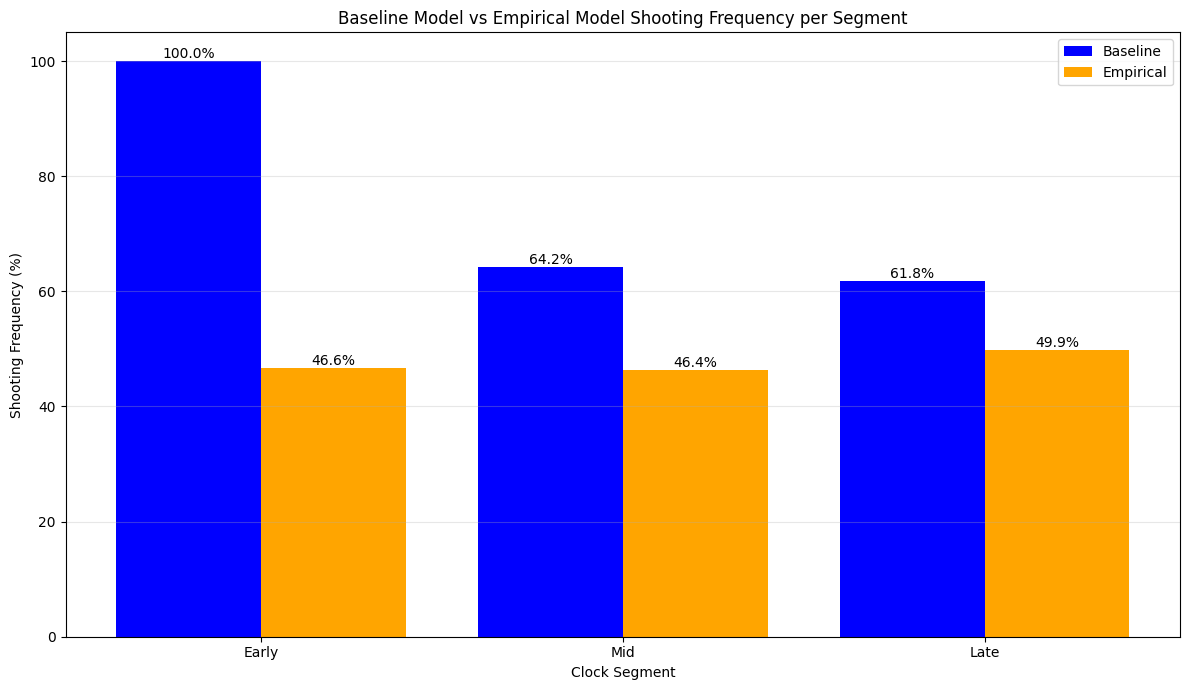

In [ ]:
"""
create a visualisation graph to show the frequencies of both shoot and drive
for each clock segment
"""

# extract baseline and empirical frequencies
baseline = [equilibria[s]['offence'][0] * 100 for s in segments]
empirical = [empirical_percentage.loc[s, 'Shoot'] if s in empirical_percentage.index else 0
             for s in segments]

# create graph
fig, br = plt.subplots(figsize=(12,7))

# label x axis as clock segments
x = np.arange(len(segments))
width = 0.40

# plot baseline bar
br.bar(x - 0.2, baseline, width, label='Baseline', color='blue')
# plot empirical bar
br.bar(x + 0.2, empirical, width, label='Empirical', color='orange')

# plot graph details
br.set_xticks(x)
br.set_ylabel('Shooting Frequency (%)')
br.set_xlabel('Clock Segment')
br.set_xticklabels(segments)
br.set_title('Baseline Model vs Empirical Model Shooting Frequency per Segment')
br.legend()
br.grid(axis='y', alpha=0.3)

# add % labels on the bars
for bars in br.containers:
  br.bar_label(bars, fmt='%.1f%%')

# show graph output
plt.tight_layout()
plt.show()